# Import Library

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import random
import keras
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import image_dataset_from_directory
from skimage.transform import resize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, DenseNet121, ResNet50
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

2026-01-02 14:46:20.428528: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767365180.881687      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767365181.008551      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
print(tf.__version__)
print(keras.__version__)

2.18.0
3.8.0


In [3]:
IMG_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 4
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.4
EPOCHS = 15
PATIENCE = 5
BATCH_SIZE = 16
SEED = 42

In [4]:
# set random seed for reproducibility
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1' 
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Load Dataset

In [5]:
# generate data paths with labels
train_data_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
filepaths = []
labels = []

folds = os.listdir(train_data_dir)
# print(folds)

for fold in folds:
    foldpath = os.path.join(train_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')

train_df = pd.concat([Fseries, Lseries], axis= 1)
train_df

,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [6]:
# Generate data paths with labels
test_data_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'
filepaths = []
labels = []

folds = os.listdir(test_data_dir)
for fold in folds:
    foldpath = os.path.join(test_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
temp_df = pd.concat([Fseries, Lseries], axis= 1)

In [7]:
# Split test set 50/50 to make a validation set
valid_df, test_df = train_test_split(temp_df, train_size= 0.5, shuffle= True, stratify=temp_df['labels'], random_state=SEED)

In [8]:
tr_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

ts_gen = ImageDataGenerator(rescale=1./255)

train_ds = tr_gen.flow_from_dataframe(
    train_df,
    x_col= 'filepaths',
    y_col= 'labels', 
    target_size= IMG_SIZE,
    class_mode= 'categorical',
    color_mode= 'rgb',
    shuffle= True,
    batch_size= BATCH_SIZE)

val_ds = ts_gen.flow_from_dataframe(
    valid_df,
    x_col= 'filepaths',
    y_col= 'labels', 
    target_size= IMG_SIZE,
    class_mode= 'categorical',
    color_mode= 'rgb',
    shuffle= False,
    batch_size= BATCH_SIZE)

test_ds = ts_gen.flow_from_dataframe(
    test_df,
    x_col= 'filepaths',
    y_col= 'labels',
    target_size= IMG_SIZE,
    class_mode= 'categorical',
    color_mode= 'rgb', 
    shuffle= False,
    batch_size= BATCH_SIZE)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


In [9]:
def print_data_distribution(datagen):
    labels = datagen.classes       
    class_indices = datagen.class_indices
    
    unique, counts = np.unique(labels, return_counts=True)
    
    distribution = {
        class_name: counts[idx]
        for class_name, idx in class_indices.items()
    }
    
    print(distribution)

print_data_distribution(train_ds)
print_data_distribution(val_ds)
print_data_distribution(test_ds)

{'glioma': 1321, 'meningioma': 1339, 'notumor': 1595, 'pituitary': 1457}
{'glioma': 150, 'meningioma': 153, 'notumor': 202, 'pituitary': 150}
{'glioma': 150, 'meningioma': 153, 'notumor': 203, 'pituitary': 150}


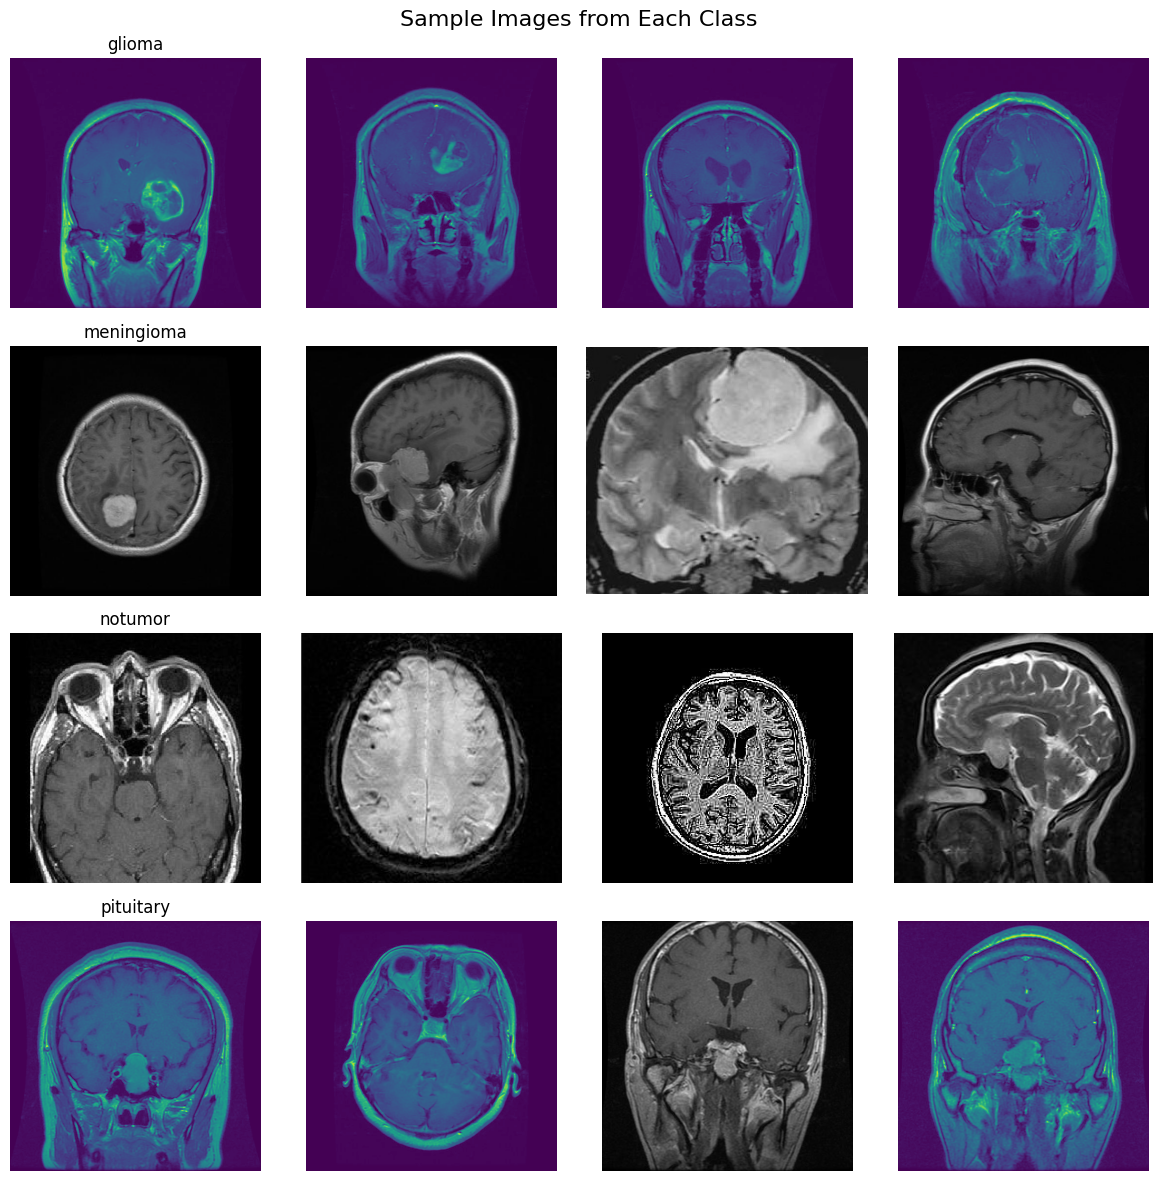

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, label in enumerate(class_names):
    sample_images = train_df[train_df['labels'] == label].sample(4)['filepaths'].values
    for j, img_path in enumerate(sample_images):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(label, fontsize=12)
plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

# Create Model, Plot, and Evaluation Modules

In [11]:
def create_model(base, mode, dropout_rate, learning_rate):

    if base == "VGG16":
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    elif base == "DenseNet121":
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    elif base == "ResNet50":
        base_model= ResNet50(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
        
    if mode=="freeze": # freeze all layers
        for layer in base_model.layers:
            layer.trainable = False
            
    elif mode=="partial":
        for layer in base_model.layers:
            layer.trainable = False  # freeze first

        for layer in base_model.layers: # unfeeze the last block/stage
            if base == "VGG16":
                if layer.name.startswith("block5"):
                    layer.trainable = True
            elif base == "DenseNet121":
                if "denseblock4" in layer.name or layer.name.startswith("conv4_block"):
                    layer.trainable = True
            elif base == "ResNet50": 
                if layer.name.startswith("conv5"):
                    layer.trainable = True
                    
    elif mode=="full": # fully fine tuning
        for layer in base_model.layers:
            layer.trainable = True
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [12]:
# Evaluation Functions (plot history & evaluation metrics)
def evaluate_model(model, test_ds, num_classes, class_names=class_names):
    y_pred_probs = model.predict(test_ds, verbose=1)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = test_ds.classes
    
    accuracy = accuracy_score(y_true_classes, y_pred_classes)
    weighted_precision = precision_score(y_true_classes, y_pred_classes, average="weighted", zero_division=0)
    weighted_recall = recall_score(y_true_classes, y_pred_classes, average="weighted", zero_division=0)
    weighted_f1 = f1_score(y_true_classes, y_pred_classes, average="weighted", zero_division=0)
    macro_precision = precision_score(y_true_classes, y_pred_classes, average="macro", zero_division=0)
    macro_recall = recall_score(y_true_classes, y_pred_classes, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true_classes, y_pred_classes, average="macro", zero_division=0)

    report = classification_report(y_true_classes, y_pred_classes, target_names=class_names if class_names else [f'Class {i}' for i in range(num_classes)])
    conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

    results = {
        "overall_accuracy": accuracy,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1_score": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1_score": macro_f1,
        "classification_report": report,
        "confusion_matrix": conf_matrix
    }

    print("\n=== MODEL EVALUATION ===")
    print(f"Overall Accuracy      : {accuracy:.4f}")
    print(f"Weighted Precision    : {weighted_precision:.4f}")
    print(f"Weighted Recall       : {weighted_recall:.4f}")
    print(f"Weighted F1-Score     : {weighted_f1:.4f}")
    print(f"Macro Precision       : {macro_precision:.4f}")
    print(f"Macro Recall          : {macro_recall:.4f}")
    print(f"Macro F1-Score        : {macro_f1:.4f}")
    print("\nClassification Report:\n", report)
    print('\n')
    # plot the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.show()

    return results
    
def plot_training_history(history, title_prefix="Model Performance"):
    hist_df = pd.DataFrame(history.history)
    hist_df['epoch'] = hist_df.index + 1
    epochs = len(hist_df)

    plt.figure(figsize=(12, 5))
    plt.plot(hist_df['epoch'], hist_df['accuracy'], label='Training Accuracy', marker='o', linestyle='-', color='blue')
    plt.plot(hist_df['epoch'], hist_df['val_accuracy'], label='Validation Accuracy', marker='s', linestyle='--', color='darkorange')
    
    plt.title(f'{title_prefix} - Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.xticks(np.arange(1, epochs + 1, max(1, epochs // 10)))
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(hist_df['epoch'], hist_df['loss'], label='Training Loss', marker='o', linestyle='-', color='blue')
    plt.plot(hist_df['epoch'], hist_df['val_loss'], label='Validation Loss', marker='s', linestyle='--', color='darkorange')
    
    min_val_loss = hist_df['val_loss'].min()
    best_epoch = hist_df['val_loss'].idxmin() + 1
    
    plt.axvline(x=best_epoch, color='red', linestyle=':', linewidth=2, label=f'Best Epoch ({best_epoch})')

    plt.title(f'{title_prefix} - Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(np.arange(1, epochs + 1, max(1, epochs // 10)))
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n--- Best Performance ---")
    print(f"Best Epoch: {best_epoch}")
    print(f"Min Validation Loss: {min_val_loss:.4f}")
    print(f"Best Validation Accuracy at Best Epoch: {hist_df.loc[hist_df.index[best_epoch-1], 'val_accuracy']:.4f}")

# DenseNet121

## Freeze

I0000 00:00:1767365222.842351      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767365222.843067      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,220 (27.35 MB)

...

 Non-trainable params: 7,037,504 (26.85 MB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1767365241.424897     115 cuda_dnn.cc:529] Loaded cuDNN version 90300


357/357 ━━━━━━━━━━━━━━━━━━━━ 166s 421ms/step - accuracy: 0.4526 - loss: 1.4303 - val_accuracy: 0.7863 - val_loss: 0.6164
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 298ms/step - accuracy: 0.7629 - loss: 0.6455 - val_accuracy: 0.8107 - val_loss: 0.5364
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 300ms/step - accuracy: 0.8132 - loss: 0.5255 - val_accuracy: 0.8198 - val_loss: 0.4983
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 300ms/step - accuracy: 0.8243 - loss: 0.4882 - val_accuracy: 0.8198 - val_loss: 0.4891
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 108s 301ms/step - accuracy: 0.8531 - loss: 0.4132 - val_accuracy: 0.8290 - val_loss: 0.4651
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 299ms/step - accuracy: 0.8628 - loss: 0.3948 - val_accuracy: 0.8519 - val_loss: 0.4278
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 106s 297ms/step - accuracy: 0.8491 - loss: 0.4030 - val_accuracy: 0.8412 - val_loss: 0.4385
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 105s 295ms/step - accuracy: 0.8685 - loss: 0.37

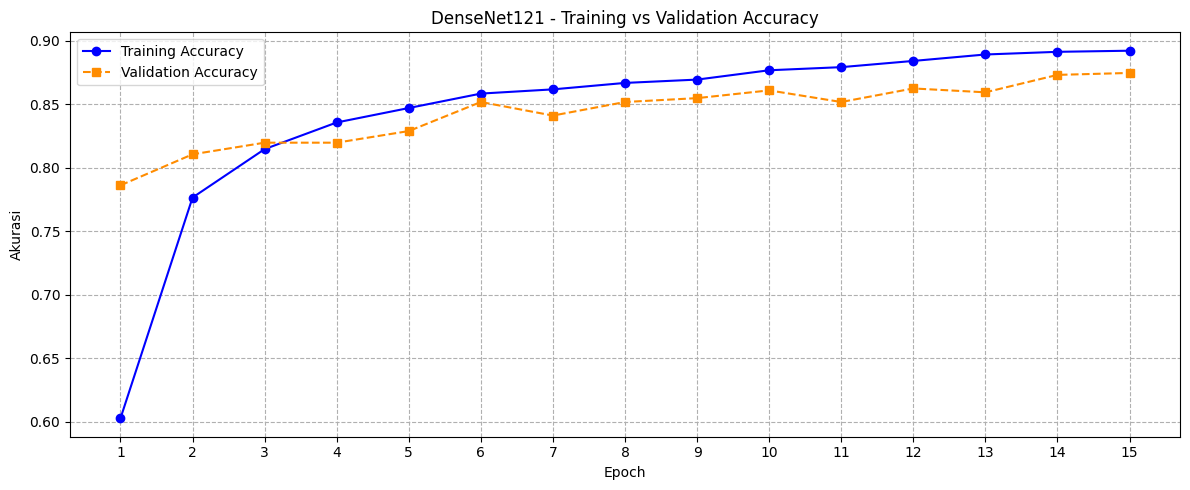

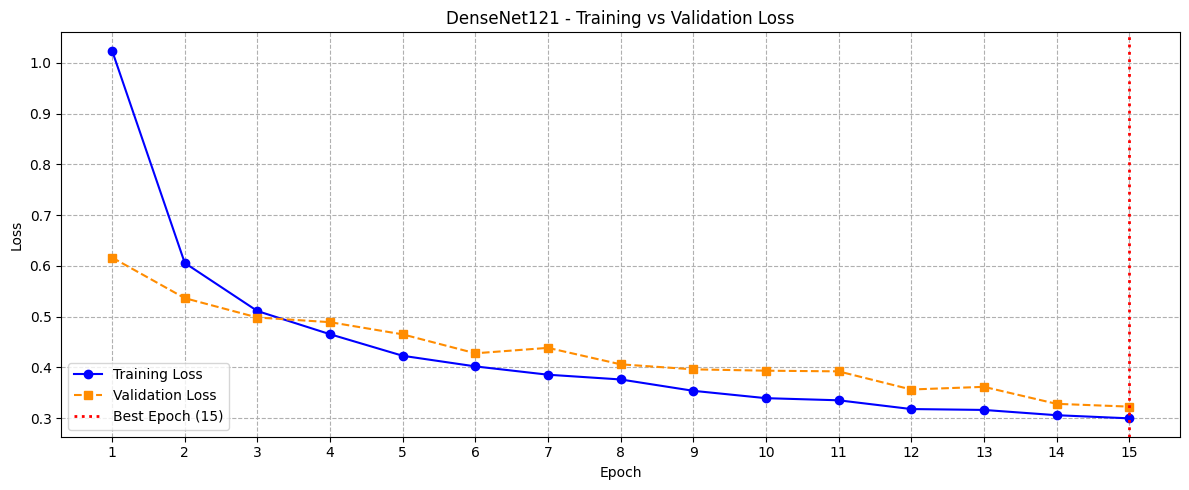


--- Best Performance ---
Best Epoch: 15
Min Validation Loss: 0.3227
Best Validation Accuracy at Best Epoch: 0.8748


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.8659
Weighted Precision    : 0.8638
Weighted Recall       : 0.8659
Weighted F1-Score     : 0.8621
Macro Precision       : 0.8589
Macro Recall          : 0.8589
Macro F1-Score        : 0.8560

Classification Report:
               precision    recall  f1-score   support

      glioma       0.87      0.83      0.85       150
  meningioma       0.80      0.67      0.73       153
     notumor       0.92      0.96      0.94       203
   pituitary       0.84      0.98      0.90       150

    accuracy                           0.87       656
   macro avg       0.86      0.86      0.86       656
weighted avg       0.86      0.87      0.86       656





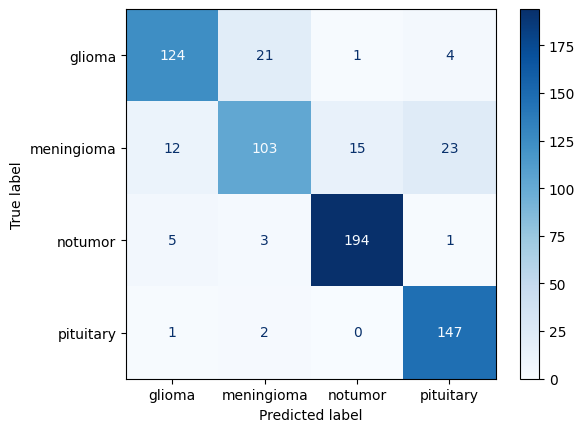

In [13]:
model_densenet121 = create_model(
    "DenseNet121",
    mode="freeze", 
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_densenet121.summary()

history_densenet121 = model_densenet121.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_densenet121, title_prefix="DenseNet121")
result_densenet121 = evaluate_model(model_densenet121, test_ds, NUM_CLASSES, class_names=class_names)

## Partial Fine-Tuning

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,220 (27.35 MB)

 Trainable params: 2,969,476 (11.33 MB)

 Non-trainable params: 4,199,744 (16.02 MB)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 160s 353ms/step - accuracy: 0.7106 - loss: 0.7217 - val_accuracy: 0.9542 - val_loss: 0.1234
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 123s 344ms/step - accuracy: 0.9463 - loss: 0.1576 - val_accuracy: 0.9771 - val_loss: 0.0811
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 121s 340ms/step - accuracy: 0.9655 - loss: 0.1068 - val_accuracy: 0.9649 - val_loss: 0.0811
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 121s 340ms/step - accuracy: 0.9752 - loss: 0.0753 - val_accuracy: 0.9557 - val_loss: 0.1124
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 120s 337ms/step - accuracy: 0.9801 - loss: 0.0612 - val_accuracy: 0.9802 - val_loss: 0.0694
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 120s 336ms/step - accuracy: 0.9834 - loss: 0.0506 - val_accuracy: 0.9939 - val_loss: 0.0330
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 121s 338ms/step - accuracy: 0.9871 - loss: 0.0388 - val_accuracy: 0.9832 - val_loss: 0.0584
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 122s 341ms/step - accuracy: 0.9901 -

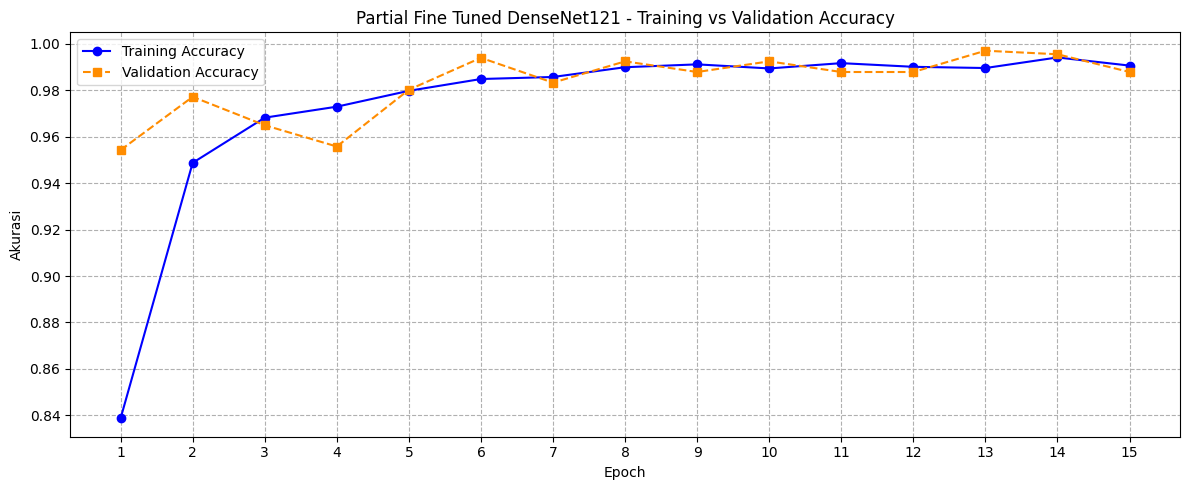

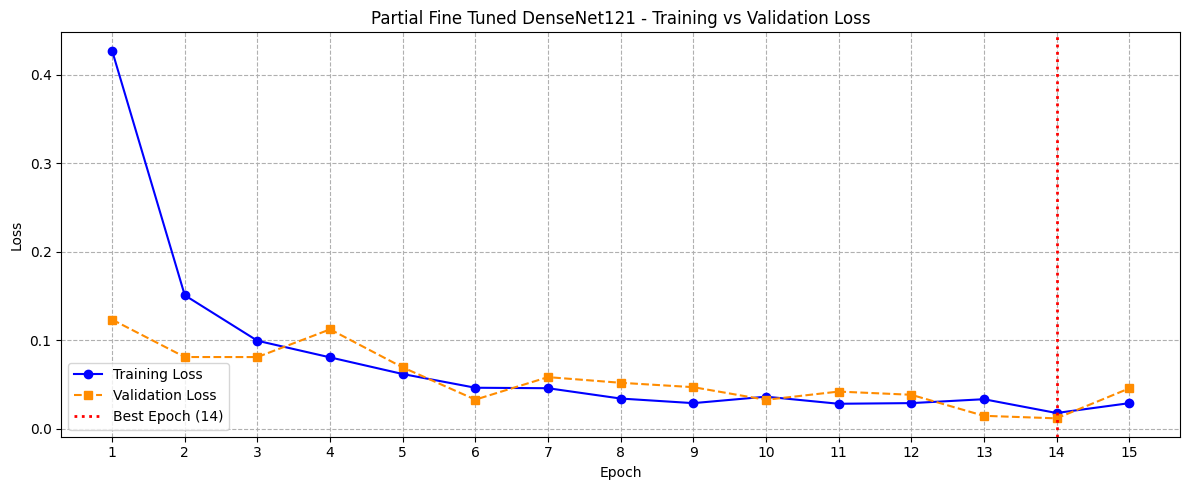


--- Best Performance ---
Best Epoch: 14
Min Validation Loss: 0.0118
Best Validation Accuracy at Best Epoch: 0.9954
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.9939
Weighted Precision    : 0.9940
Weighted Recall       : 0.9939
Weighted F1-Score     : 0.9939
Macro Precision       : 0.9934
Macro Recall          : 0.9934
Macro F1-Score        : 0.9934

Classification Report:
               precision    recall  f1-score   support

      glioma       1.00      0.99      1.00       150
  meningioma       0.99      0.98      0.99       153
     notumor       1.00      1.00      1.00       203
   pituitary       0.98      1.00      0.99       150

    accuracy                           0.99       656
   macro avg       0.99      0.99      0.99       656
weighted avg       0.99      0.99      0.99       656





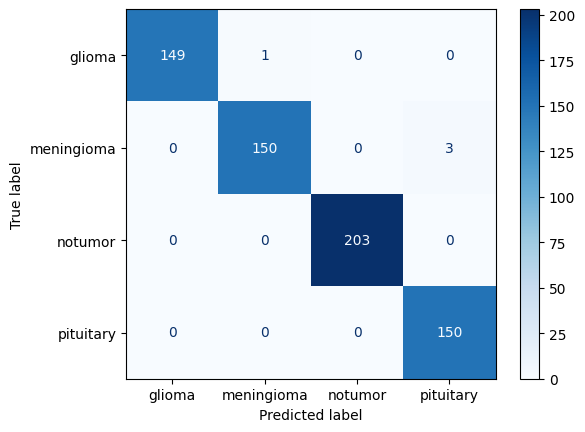

In [14]:
model_finetuned_densenet121 = create_model(
    "DenseNet121",
    mode="partial", 
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_finetuned_densenet121.summary()

history_finetuned_densenet121 = model_finetuned_densenet121.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_finetuned_densenet121, title_prefix="Partial Fine Tuned DenseNet121")
result_finetuned_densenet121 = evaluate_model(model_finetuned_densenet121, test_ds, NUM_CLASSES, class_names=class_names)

## Fully Fine-Tuning

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,220 (27.35 MB)

 Trainable params: 7,085,572 (27.03 MB)

 Non-trainable params: 83,648 (326.75 KB)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 265s 558ms/step - accuracy: 0.7664 - loss: 0.5898 - val_accuracy: 0.9542 - val_loss: 0.1257
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 193s 541ms/step - accuracy: 0.9447 - loss: 0.1742 - val_accuracy: 0.9573 - val_loss: 0.1064
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 193s 542ms/step - accuracy: 0.9516 - loss: 0.1464 - val_accuracy: 0.8931 - val_loss: 0.2933
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 193s 540ms/step - accuracy: 0.9642 - loss: 0.1013 - val_accuracy: 0.9695 - val_loss: 0.0886
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 192s 539ms/step - accuracy: 0.9836 - loss: 0.0577 - val_accuracy: 0.9649 - val_loss: 0.1003
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 195s 546ms/step - accuracy: 0.9804 - loss: 0.0597 - val_accuracy: 0.9450 - val_loss: 0.1566
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 193s 540ms/step - accuracy: 0.9847 - loss: 0.0437 - val_accuracy: 0.9573 - val_loss: 0.1268
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 193s 541ms/step - accuracy: 0.9818 -

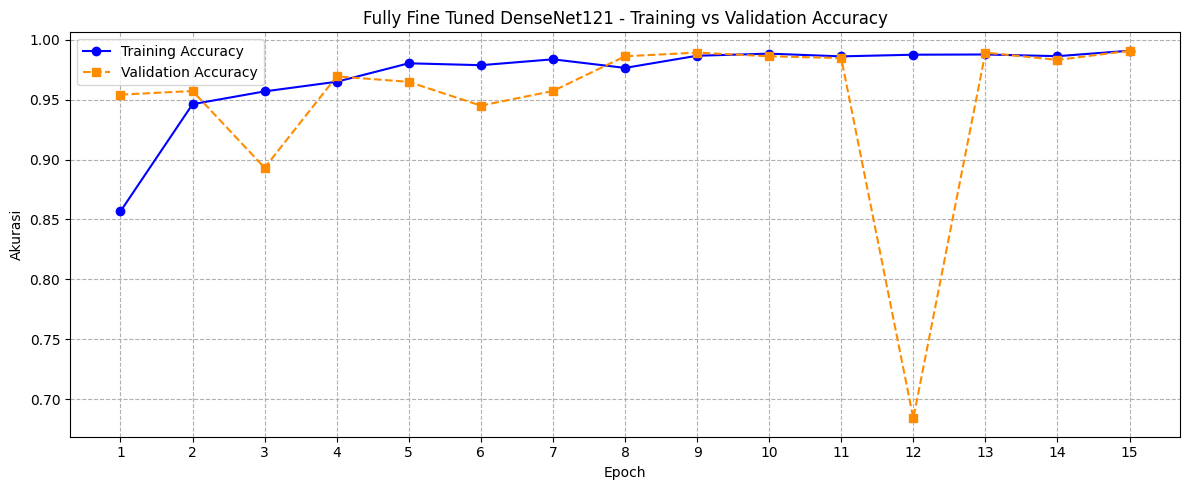

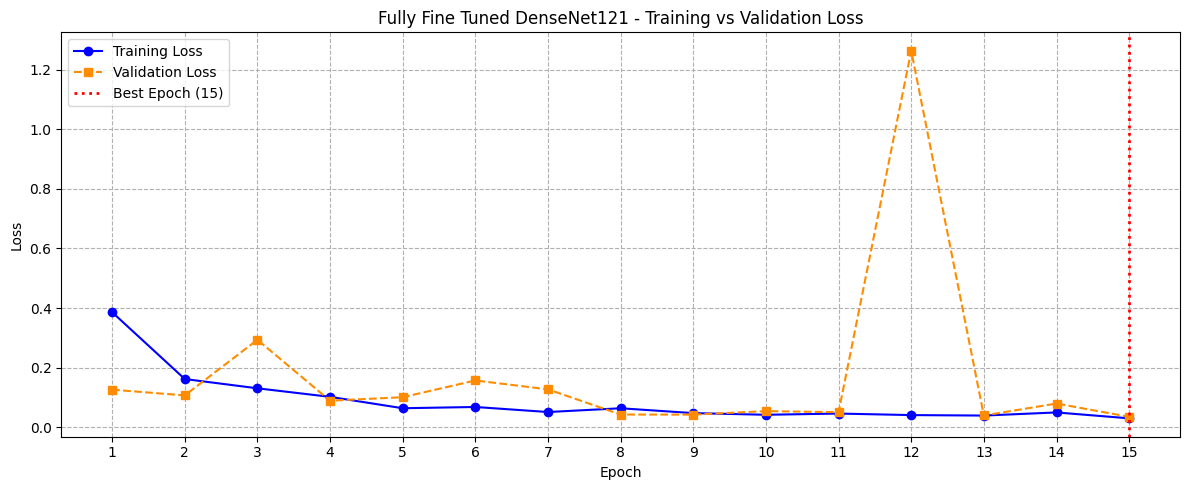


--- Best Performance ---
Best Epoch: 15
Min Validation Loss: 0.0344
Best Validation Accuracy at Best Epoch: 0.9908
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.9832
Weighted Precision    : 0.9835
Weighted Recall       : 0.9832
Weighted F1-Score     : 0.9832
Macro Precision       : 0.9833
Macro Recall          : 0.9819
Macro F1-Score        : 0.9824

Classification Report:
               precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       150
  meningioma       0.99      0.95      0.97       153
     notumor       0.99      1.00      0.99       203
   pituitary       0.96      1.00      0.98       150

    accuracy                           0.98       656
   macro avg       0.98      0.98      0.98       656
weighted avg       0.98      0.98      0.98       656





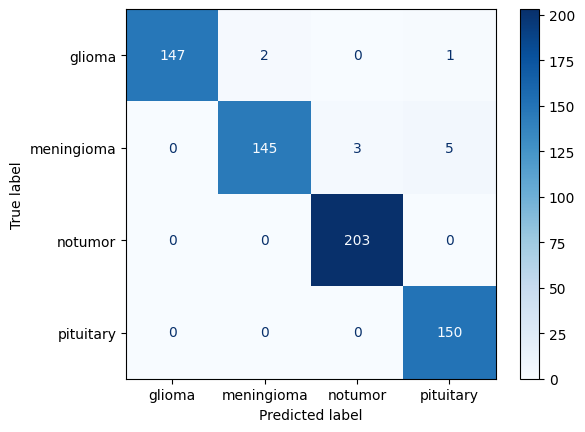

In [15]:
model_fullyfinetuned_densenet121 = create_model(
    "DenseNet121",
    mode="full", 
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_fullyfinetuned_densenet121.summary()

history_fullyfinetuned_densenet121 = model_fullyfinetuned_densenet121.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_fullyfinetuned_densenet121, title_prefix="Fully Fine Tuned DenseNet121")
result_fullyfinetuned_densenet121 = evaluate_model(model_fullyfinetuned_densenet121, test_ds, NUM_CLASSES, class_names=class_names)

# VGG16

## Freeze

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 296ms/step - accuracy: 0.3226 - loss: 1.3877 - val_accuracy: 0.5588 - val_loss: 1.1645
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 104s 292ms/step - accuracy: 0.5506 - loss: 1.1301 - val_accuracy: 0.5878 - val_loss: 1.0221
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 289ms/step - accuracy: 0.6494 - loss: 0.9668 - val_accuracy: 0.6733 - val_loss: 0.9072
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 289ms/step - accuracy: 0.6985 - loss: 0.8570 - val_accuracy: 0.6947 - val_loss: 0.8495
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 104s 290ms/step - accuracy: 0.7179 - loss: 0.7813 - val_accuracy: 0.7145 - val_loss: 0.8088
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 289ms/step - accuracy: 0.7446 - loss: 0.7395 - val_accuracy: 0.7160 - val_loss: 0.7661
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 290ms/step - accuracy: 0.7626 - loss: 0.6864 - val_accuracy: 0.7450 - val_loss: 0.7200
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 105s 293ms/step - accuracy: 0.7610 -

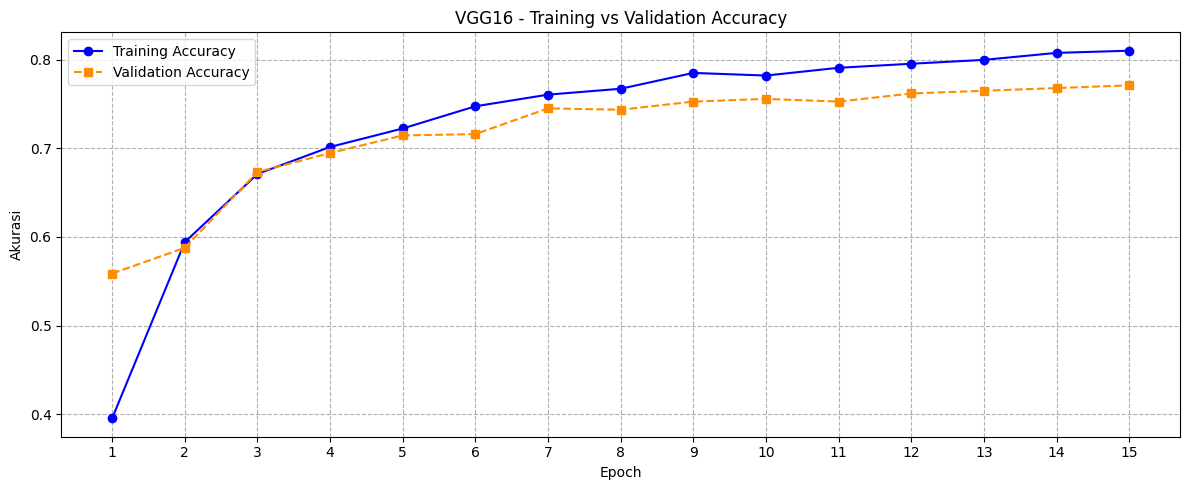

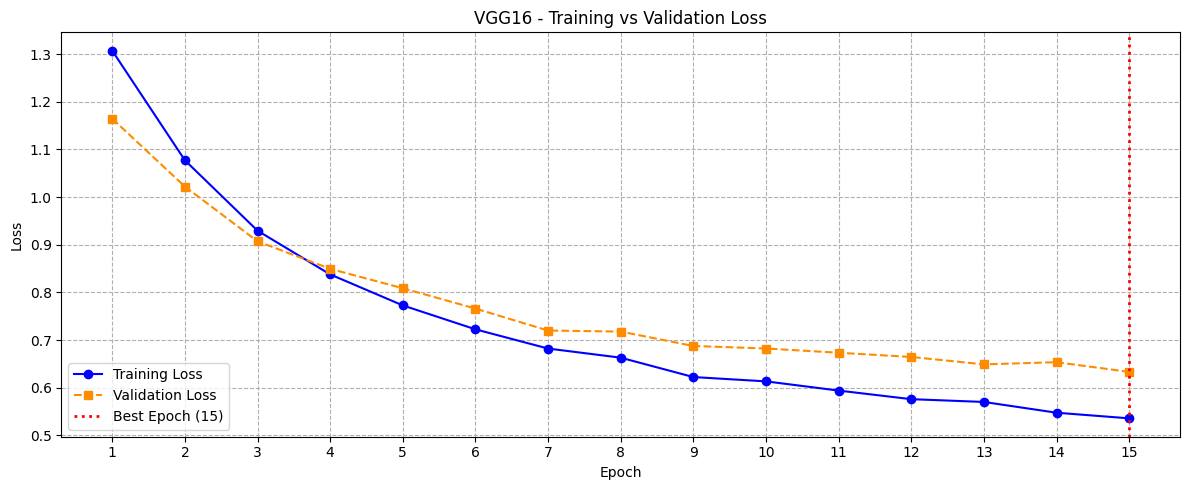


--- Best Performance ---
Best Epoch: 15
Min Validation Loss: 0.6332
Best Validation Accuracy at Best Epoch: 0.7710
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.7851
Weighted Precision    : 0.7820
Weighted Recall       : 0.7851
Weighted F1-Score     : 0.7728
Macro Precision       : 0.7756
Macro Recall          : 0.7733
Macro F1-Score        : 0.7630

Classification Report:
               precision    recall  f1-score   support

      glioma       0.84      0.71      0.77       150
  meningioma       0.68      0.46      0.55       153
     notumor       0.86      0.94      0.90       203
   pituitary       0.72      0.98      0.83       150

    accuracy                           0.79       656
   macro avg       0.78      0.77      0.76       656
weighted avg       0.78      0.79      0.77       656





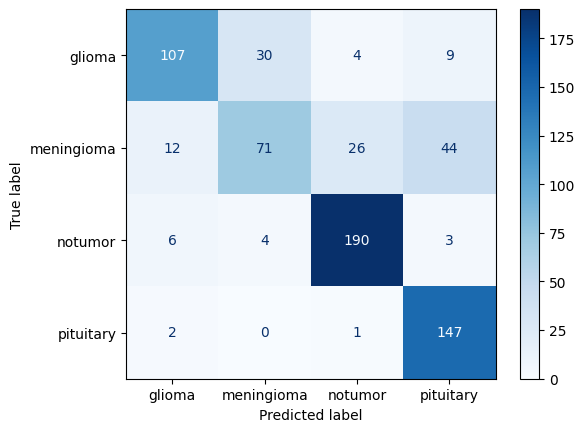

In [17]:
model_vgg16 = create_model(
    "VGG16",
    mode="freeze",
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_vgg16.summary()

history_vgg16 = model_vgg16.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_vgg16, title_prefix="VGG16")
result_vgg16 = evaluate_model(model_vgg16, test_ds, NUM_CLASSES, class_names=class_names)

## Partial Fine-Tuning

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 294ms/step - accuracy: 0.6678 - loss: 0.8009 - val_accuracy: 0.8595 - val_loss: 0.4066
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 290ms/step - accuracy: 0.8891 - loss: 0.3190 - val_accuracy: 0.8458 - val_loss: 0.3989
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 105s 295ms/step - accuracy: 0.9163 - loss: 0.2392 - val_accuracy: 0.9038 - val_loss: 0.2490
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 106s 298ms/step - accuracy: 0.9349 - loss: 0.1893 - val_accuracy: 0.9145 - val_loss: 0.2525
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 106s 296ms/step - accuracy: 0.9505 - loss: 0.1574 - val_accuracy: 0.9374 - val_loss: 0.1644
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 105s 295ms/step - accuracy: 0.9605 - loss: 0.1163 - val_accuracy: 0.9603 - val_loss: 0.1261
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 105s 293ms/step - accuracy: 0.9701 - loss: 0.0952 - val_accuracy: 0.9695 - val_loss: 0.0948
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 104s 291ms/step - accuracy: 0.9703 -

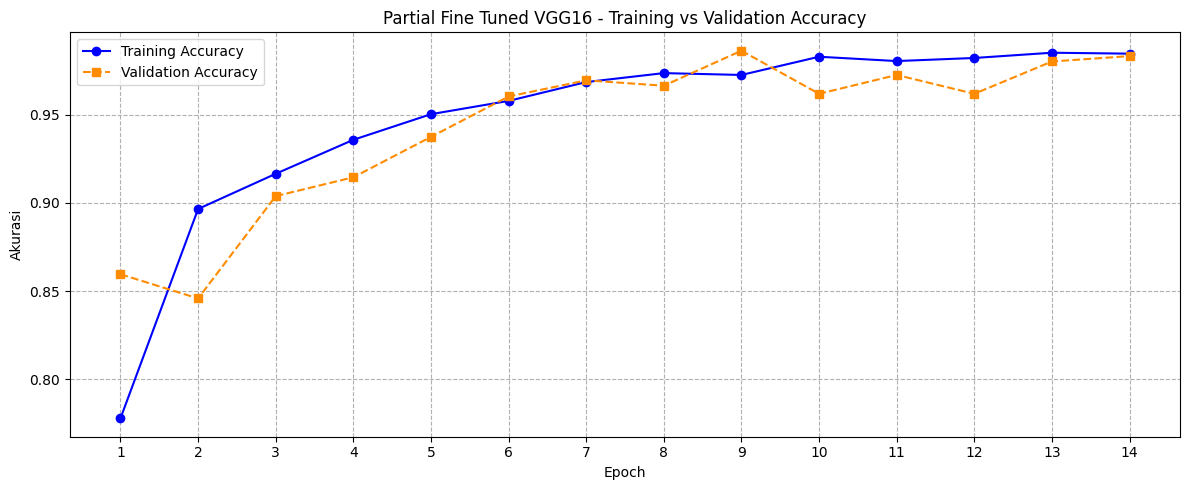

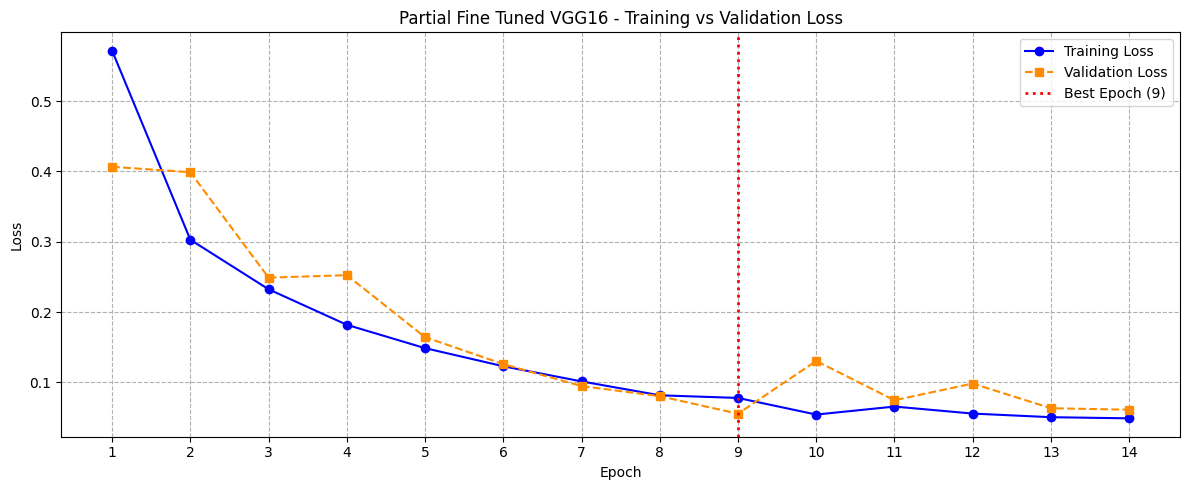


--- Best Performance ---
Best Epoch: 9
Min Validation Loss: 0.0556
Best Validation Accuracy at Best Epoch: 0.9863
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.9771
Weighted Precision    : 0.9772
Weighted Recall       : 0.9771
Weighted F1-Score     : 0.9771
Macro Precision       : 0.9753
Macro Recall          : 0.9757
Macro F1-Score        : 0.9754

Classification Report:
               precision    recall  f1-score   support

      glioma       0.97      0.96      0.97       150
  meningioma       0.96      0.95      0.96       153
     notumor       1.00      1.00      1.00       203
   pituitary       0.97      0.99      0.98       150

    accuracy                           0.98       656
   macro avg       0.98      0.98      0.98       656
weighted avg       0.98      0.98      0.98       656





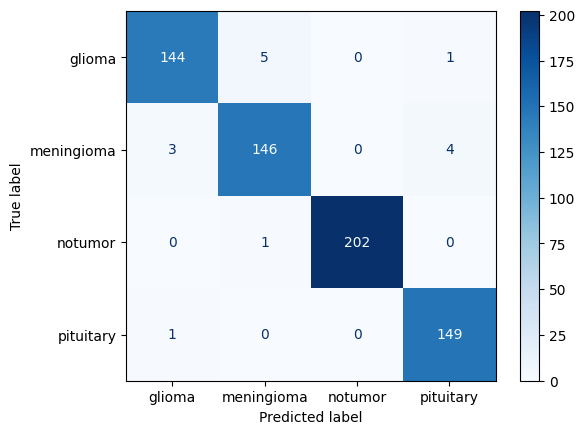

In [18]:
model_finetuned_vgg16 = create_model(
    "VGG16",
    mode="partial",
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_finetuned_vgg16.summary()

history_finetuned_vgg16 = model_finetuned_vgg16.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_finetuned_vgg16, title_prefix="Partial Fine Tuned VGG16")
result_finetuned_vgg16 = evaluate_model(model_finetuned_vgg16, test_ds, NUM_CLASSES, class_names=class_names)

## Fully Fine-Tuning

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 14,780,868 (56.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 160s 438ms/step - accuracy: 0.4465 - loss: 1.1383 - val_accuracy: 0.7878 - val_loss: 0.5651
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 158s 443ms/step - accuracy: 0.8104 - loss: 0.5087 - val_accuracy: 0.8794 - val_loss: 0.3319
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 156s 438ms/step - accuracy: 0.8842 - loss: 0.3177 - val_accuracy: 0.8885 - val_loss: 0.3010
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 155s 434ms/step - accuracy: 0.9151 - loss: 0.2430 - val_accuracy: 0.8718 - val_loss: 0.5029
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 155s 435ms/step - accuracy: 0.9307 - loss: 0.2225 - val_accuracy: 0.9359 - val_loss: 0.1927
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 156s 437ms/step - accuracy: 0.9566 - loss: 0.1365 - val_accuracy: 0.9496 - val_loss: 0.1432
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 156s 438ms/step - accuracy: 0.9530 - loss: 0.1563 - val_accuracy: 0.9634 - val_loss: 0.1153
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 156s 436ms/step - accuracy: 0.9623 -

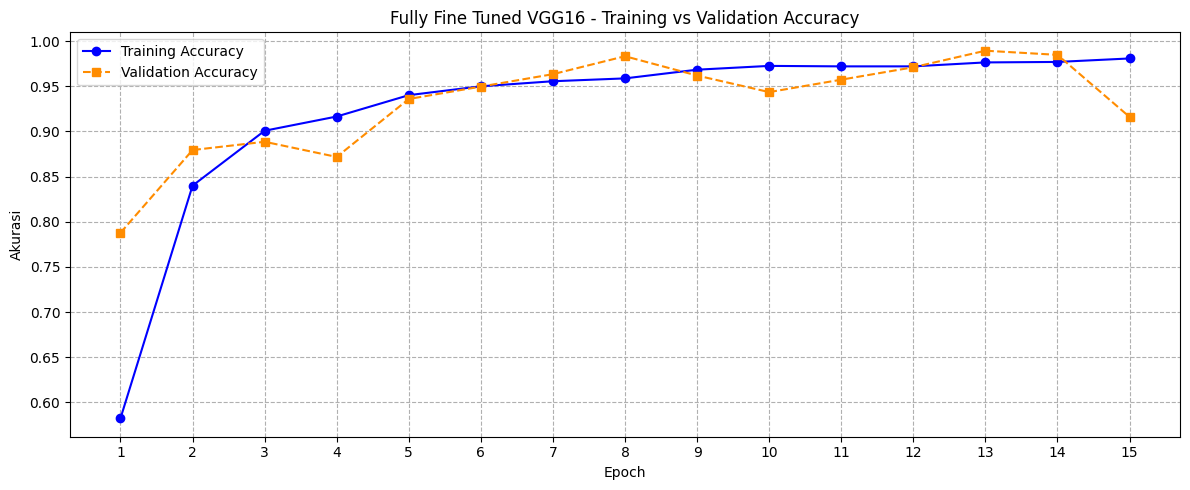

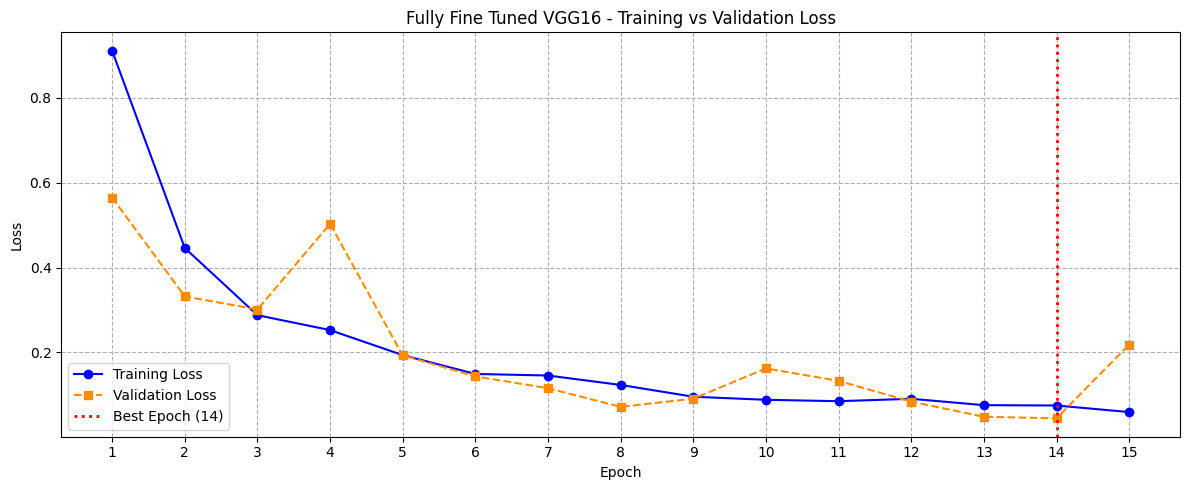


--- Best Performance ---
Best Epoch: 14
Min Validation Loss: 0.0442
Best Validation Accuracy at Best Epoch: 0.9847
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.9863
Weighted Precision    : 0.9864
Weighted Recall       : 0.9863
Weighted F1-Score     : 0.9863
Macro Precision       : 0.9873
Macro Recall          : 0.9852
Macro F1-Score        : 0.9862

Classification Report:
               precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       150
  meningioma       0.99      0.97      0.98       153
     notumor       0.98      1.00      0.99       203
   pituitary       1.00      0.99      0.99       150

    accuracy                           0.99       656
   macro avg       0.99      0.99      0.99       656
weighted avg       0.99      0.99      0.99       656





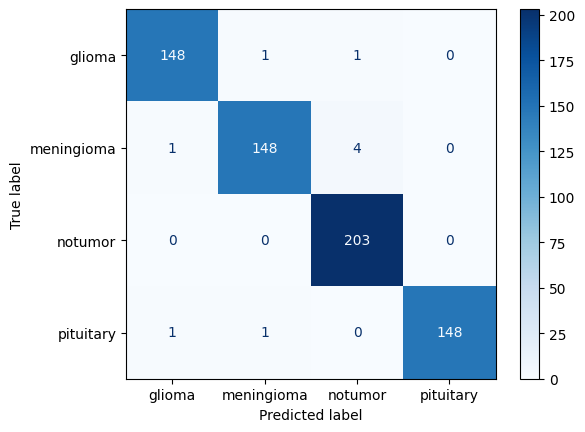

In [19]:
model_fullyfinetuned_vgg16 = create_model(
    "VGG16",
    mode="full",
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_fullyfinetuned_vgg16.summary()

history_fullyfinetuned_vgg16 = model_fullyfinetuned_vgg16.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_fullyfinetuned_vgg16, title_prefix="Fully Fine Tuned VGG16")
result_fullyfinetuned_vgg16 = evaluate_model(model_fullyfinetuned_vgg16, test_ds, NUM_CLASSES, class_names=class_names)

# ResNet50

## Freeze

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 114s 301ms/step - accuracy: 0.3212 - loss: 1.4255 - val_accuracy: 0.4443 - val_loss: 1.1973
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 104s 291ms/step - accuracy: 0.4321 - loss: 1.1888 - val_accuracy: 0.4977 - val_loss: 1.1844
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 104s 290ms/step - accuracy: 0.4643 - loss: 1.1383 - val_accuracy: 0.4427 - val_loss: 1.1793
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 104s 291ms/step - accuracy: 0.4773 - loss: 1.1169 - val_accuracy: 0.4763 - val_loss: 1.1325
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 105s 293ms/step - accuracy: 0.5015 - loss: 1.1046 - val_accuracy: 0.5252 - val_loss: 1.1240
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 106s 296ms/step - accuracy: 0.5168 - loss: 1.0769 - val_accuracy: 0.5221 - val_loss: 1.1290
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 106s 297ms/step - accuracy: 0.5143 - loss: 1.0792 - val_accuracy: 0.5344 - val_loss: 1.1183
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 300ms/step - accuracy: 0.5270 -

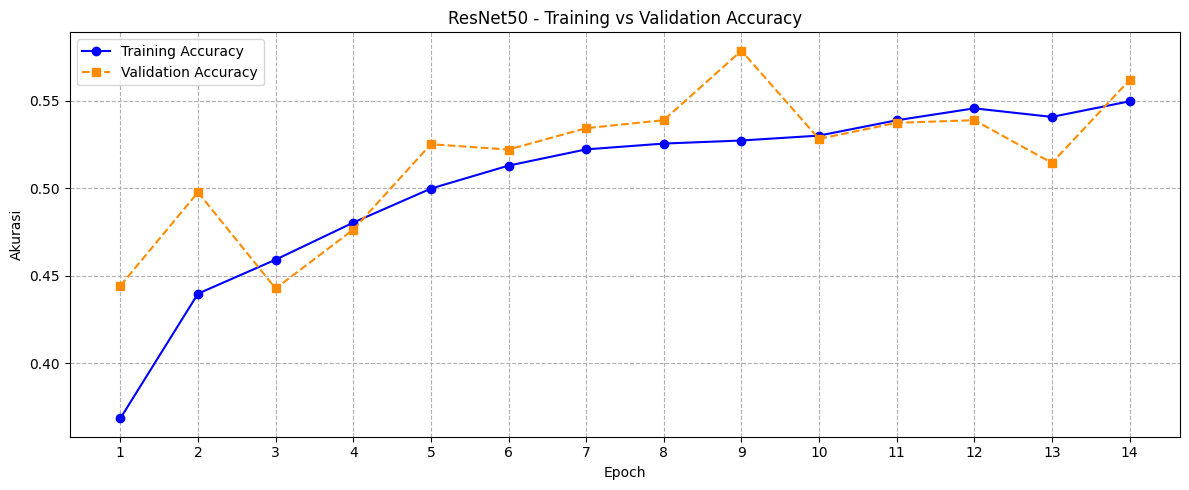

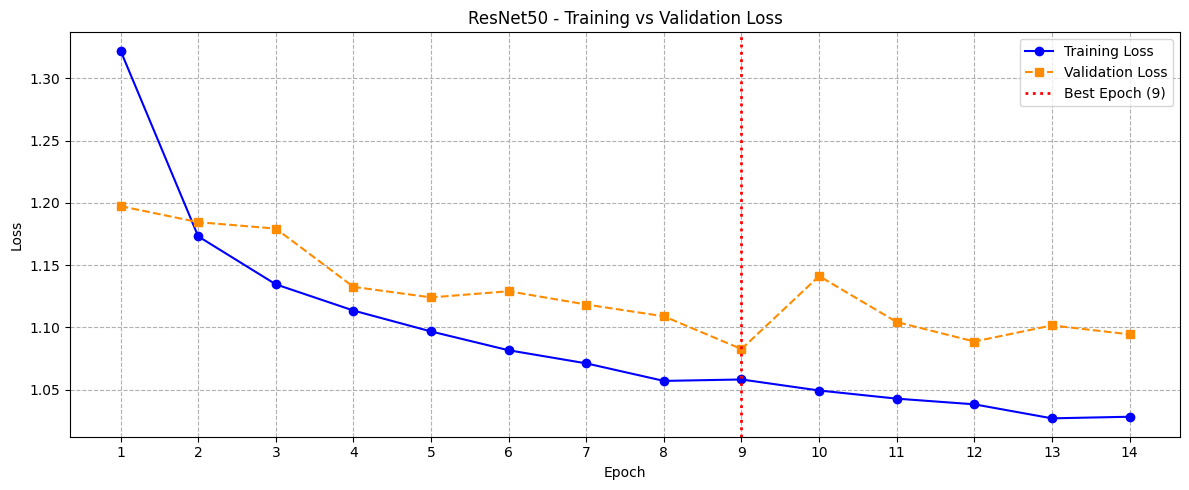


--- Best Performance ---
Best Epoch: 9
Min Validation Loss: 1.0826
Best Validation Accuracy at Best Epoch: 0.5786
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.5549
Weighted Precision    : 0.5405
Weighted Recall       : 0.5549
Weighted F1-Score     : 0.5376
Macro Precision       : 0.5347
Macro Recall          : 0.5366
Macro F1-Score        : 0.5257

Classification Report:
               precision    recall  f1-score   support

      glioma       0.52      0.53      0.53       150
  meningioma       0.46      0.25      0.33       153
     notumor       0.61      0.78      0.68       203
   pituitary       0.55      0.58      0.56       150

    accuracy                           0.55       656
   macro avg       0.53      0.54      0.53       656
weighted avg       0.54      0.55      0.54       656





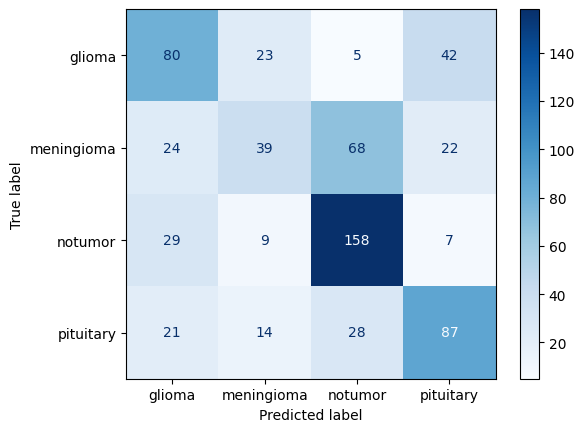

In [20]:
model_resnet50 = create_model(
    "ResNet50",
    mode="freeze",
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_resnet50.summary()

history_resnet50 = model_resnet50.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_resnet50, title_prefix="ResNet50")
result_resnet50 = evaluate_model(model_resnet50, test_ds, NUM_CLASSES, class_names=class_names)

## Partial Fine-Tuning

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 15,238,788 (58.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 122s 311ms/step - accuracy: 0.4987 - loss: 1.1228 - val_accuracy: 0.4687 - val_loss: 1.2028
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 109s 304ms/step - accuracy: 0.6014 - loss: 0.9611 - val_accuracy: 0.6015 - val_loss: 0.9744
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 108s 303ms/step - accuracy: 0.6238 - loss: 0.8851 - val_accuracy: 0.5328 - val_loss: 1.1270
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 109s 304ms/step - accuracy: 0.6558 - loss: 0.8236 - val_accuracy: 0.7115 - val_loss: 0.7817
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 108s 303ms/step - accuracy: 0.6599 - loss: 0.8034 - val_accuracy: 0.6504 - val_loss: 0.9106
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 301ms/step - accuracy: 0.6709 - loss: 0.8113 - val_accuracy: 0.5832 - val_loss: 1.0950
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 107s 300ms/step - accuracy: 0.6830 - loss: 0.7632 - val_accuracy: 0.6809 - val_loss: 0.7696
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 108s 302ms/step - accuracy: 0.6967 -

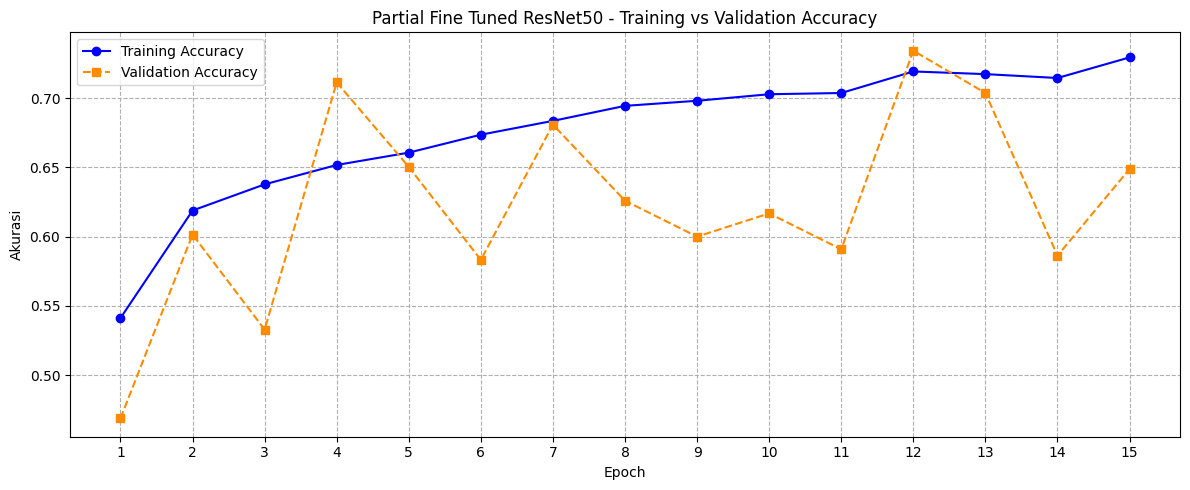

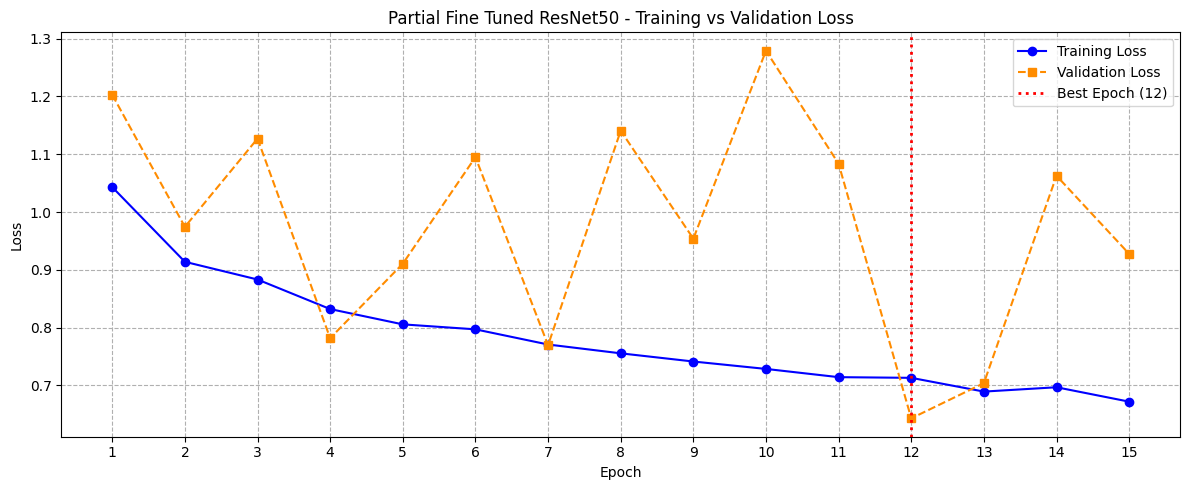


--- Best Performance ---
Best Epoch: 12
Min Validation Loss: 0.6430
Best Validation Accuracy at Best Epoch: 0.7344
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.7210
Weighted Precision    : 0.7080
Weighted Recall       : 0.7210
Weighted F1-Score     : 0.7022
Macro Precision       : 0.7022
Macro Recall          : 0.7026
Macro F1-Score        : 0.6899

Classification Report:
               precision    recall  f1-score   support

      glioma       0.70      0.67      0.68       150
  meningioma       0.62      0.36      0.46       153
     notumor       0.78      0.95      0.86       203
   pituitary       0.71      0.83      0.76       150

    accuracy                           0.72       656
   macro avg       0.70      0.70      0.69       656
weighted avg       0.71      0.72      0.70       656





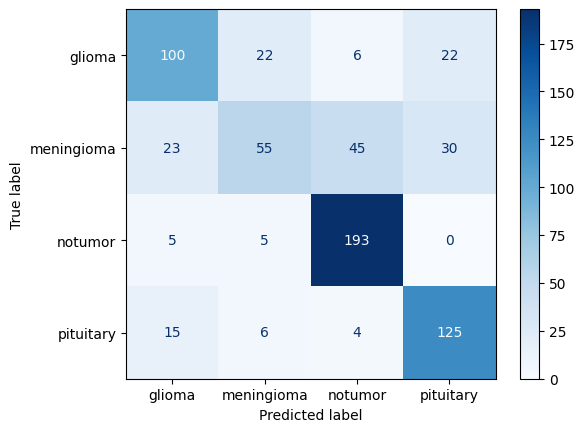

In [21]:
model_finetuned_resnet50 = create_model(
    "ResNet50",
    mode="partial",
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_finetuned_resnet50.summary()

history_finetuned_resnet50 = model_finetuned_resnet50.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_finetuned_resnet50, title_prefix="Partial Fine Tuned ResNet50")
result_finetuned_resnet50 = evaluate_model(model_finetuned_resnet50, test_ds, NUM_CLASSES, class_names=class_names)

## Fully Fine-Tuning

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 23,797,380 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 247s 596ms/step - accuracy: 0.7964 - loss: 0.5394 - val_accuracy: 0.2534 - val_loss: 1.7732
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 209s 586ms/step - accuracy: 0.9411 - loss: 0.1898 - val_accuracy: 0.6290 - val_loss: 0.9141
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 209s 584ms/step - accuracy: 0.9625 - loss: 0.1155 - val_accuracy: 0.9389 - val_loss: 0.1572
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 208s 582ms/step - accuracy: 0.9662 - loss: 0.1022 - val_accuracy: 0.9740 - val_loss: 0.0676
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 208s 582ms/step - accuracy: 0.9694 - loss: 0.0982 - val_accuracy: 0.9389 - val_loss: 0.2149
Epoch 6/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 207s 581ms/step - accuracy: 0.9791 - loss: 0.0653 - val_accuracy: 0.9847 - val_loss: 0.0605
Epoch 7/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 208s 583ms/step - accuracy: 0.9762 - loss: 0.0782 - val_accuracy: 0.9847 - val_loss: 0.0507
Epoch 8/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 207s 580ms/step - accuracy: 0.9803 -

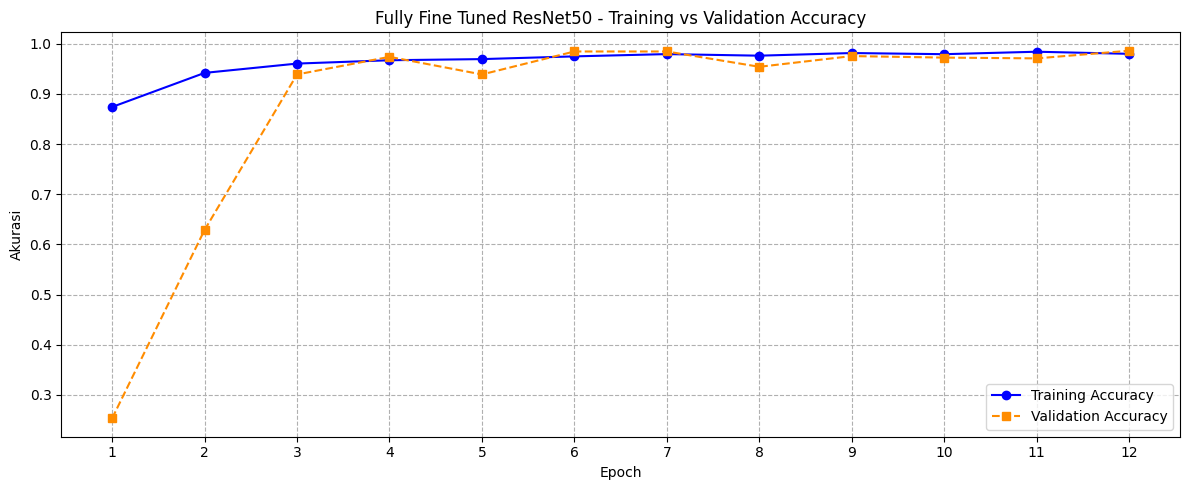

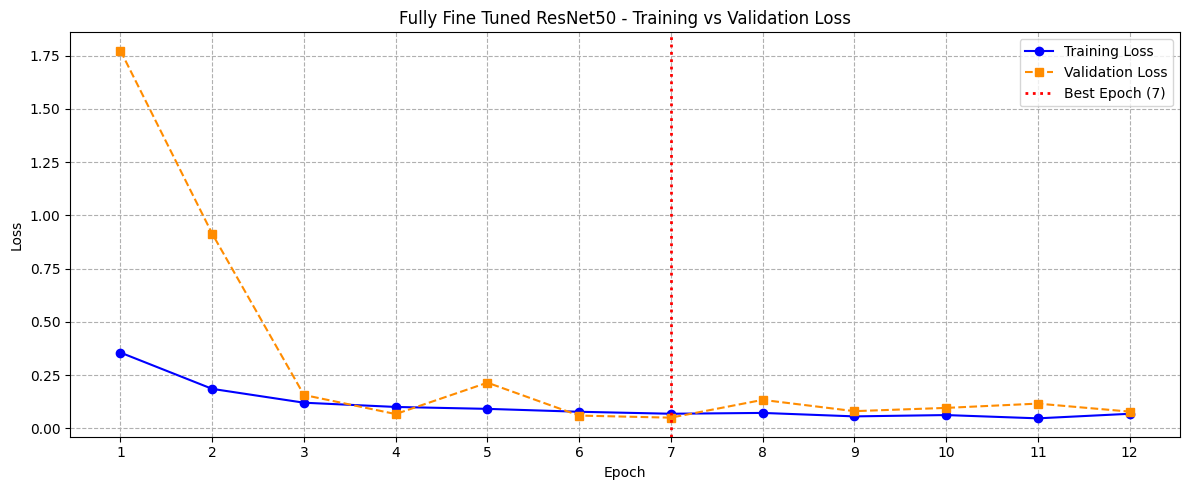


--- Best Performance ---
Best Epoch: 7
Min Validation Loss: 0.0507
Best Validation Accuracy at Best Epoch: 0.9847
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step

=== MODEL EVALUATION ===
Overall Accuracy      : 0.9924
Weighted Precision    : 0.9924
Weighted Recall       : 0.9924
Weighted F1-Score     : 0.9924
Macro Precision       : 0.9926
Macro Recall          : 0.9918
Macro F1-Score        : 0.9922

Classification Report:
               precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       150
  meningioma       0.99      0.98      0.98       153
     notumor       0.99      1.00      1.00       203
   pituitary       1.00      0.99      1.00       150

    accuracy                           0.99       656
   macro avg       0.99      0.99      0.99       656
weighted avg       0.99      0.99      0.99       656





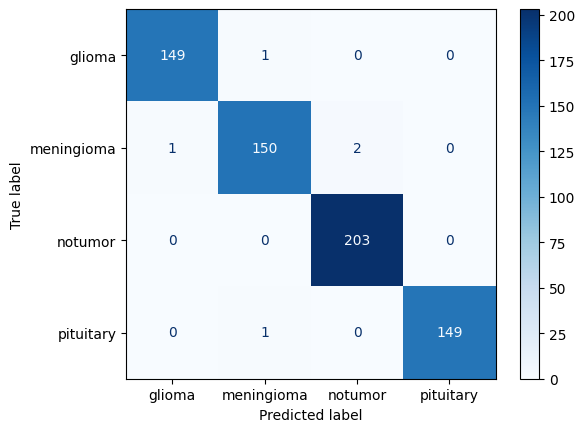

In [22]:
model_fullyfinetuned_resnet50 = create_model(
    "ResNet50",
    mode="full",
    dropout_rate = DROPOUT_RATE,
    learning_rate = LEARNING_RATE
)

model_fullyfinetuned_resnet50.summary()

history_fullyfinetuned_resnet50 = model_fullyfinetuned_resnet50.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data = val_ds,
    callbacks=EarlyStopping(monitor='val_loss', patience=PATIENCE, verbose=1, restore_best_weights=True)
)

plot_training_history(history_fullyfinetuned_resnet50, title_prefix="Fully Fine Tuned ResNet50")
result_fullyfinetuned_resnet50 = evaluate_model(model_fullyfinetuned_resnet50, test_ds, NUM_CLASSES, class_names=class_names)

In [23]:
# save models
model_densenet121.save('densenet121_tumor.keras')
model_finetuned_densenet121.save('finetuned_densenet121_tumor.keras')
model_fullyfinetuned_densenet121.save('fullyfinetuned_densenet121_tumor.keras')
model_vgg16.save('vgg16_tumor.keras')
model_finetuned_vgg16.save('finetuned_vgg16_tumor.keras')
model_fullyfinetuned_vgg16.save('fullyfinetuned_vgg16_tumor.keras')
model_resnet50.save('resnet50_tumor.keras')
model_finetuned_resnet50.save('finetuned_resnet50_tumor.keras')
model_fullyfinetuned_resnet50.save('fullyfinetuned_resnet50_tumor.keras')
print('models are saved!')

models are saved!
